## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [8]:
df.describe(include='all')

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000,50000,50000.000000,50000.00000,50000.00000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,2,3,NaN,NaN,NaN,NaN,799,104,NaN,NaN,NaN,NaN,NaN
top,NaN,Internet,RoundTrip,NaN,NaN,NaN,NaN,AKLKUL,Australia,NaN,NaN,NaN,NaN,NaN
freq,NaN,44382,49497,NaN,NaN,NaN,NaN,2680,17872,NaN,NaN,NaN,NaN,NaN
mean,1.591240,NaN,NaN,84.940480,23.04456,9.06634,3.814420,NaN,NaN,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,NaN,NaN,90.451378,33.88767,5.41266,1.992792,NaN,NaN,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,NaN,NaN,0.000000,0.00000,0.00000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,NaN,NaN,21.000000,5.00000,5.00000,2.000000,NaN,NaN,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,NaN,NaN,51.000000,17.00000,9.00000,4.000000,NaN,NaN,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,NaN,NaN,115.000000,28.00000,13.00000,5.000000,NaN,NaN,1.000000,1.000000,1.000000,8.830000,0.000000


In [9]:
df["booking_origin"].value_counts().head(10)

booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

In [10]:
# Frequency-encode the two high-cardinality columns
df["route_frequency"] = df["route"].map(df["route"].value_counts())
df["booking_origin_frequency"] = df["booking_origin"].map(df["booking_origin"].value_counts())

print(df[["route", "route_frequency", "booking_origin", "booking_origin_frequency"]].head())

    route  route_frequency booking_origin  booking_origin_frequency
0  AKLDEL               20    New Zealand                      1074
1  AKLDEL               20    New Zealand                      1074
2  AKLDEL               20          India                      1270
3  AKLDEL               20    New Zealand                      1074
4  AKLDEL               20          India                      1270


Step 2: Check those outliers before deciding what to do with them

In [11]:
print(df["purchase_lead"].describe())
print()
print(df["length_of_stay"].describe())
print()

count    50000.000000
mean        84.940480
std         90.451378
min          0.000000
25%         21.000000
50%         51.000000
75%        115.000000
max        867.000000
Name: purchase_lead, dtype: float64

count    50000.00000
mean        23.04456
std         33.88767
min          0.00000
25%          5.00000
50%         17.00000
75%         28.00000
max        778.00000
Name: length_of_stay, dtype: float64



In [12]:
# how many rows are "extreme"?
print("purchase_lead > 365:", (df["purchase_lead"] > 365).sum())
print("length_of_stay > 180:", (df["length_of_stay"] > 180).sum())

purchase_lead > 365: 838
length_of_stay > 180: 375


In [13]:
# Cap outliers at sensible thresholds (winsorizing)
df["purchase_lead"] = df["purchase_lead"].clip(upper=365)
df["length_of_stay"] = df["length_of_stay"].clip(upper=180)

# Confirm the cap worked
print(df["purchase_lead"].describe())
print(df["length_of_stay"].describe())

count    50000.000000
mean        84.302080
std         88.176909
min          0.000000
25%         21.000000
50%         51.000000
75%        115.000000
max        365.000000
Name: purchase_lead, dtype: float64
count    50000.000000
mean        22.348600
std         28.395819
min          0.000000
25%          5.000000
50%         17.000000
75%         28.000000
max        180.000000
Name: length_of_stay, dtype: float64


In [14]:
# New engineered features
df["total_extras"] = df["wants_extra_baggage"] + df["wants_preferred_seat"] + df["wants_in_flight_meals"]
df["is_weekend_flight"] = df["flight_day"].isin([6, 7]).astype(int)  # Sat=6, Sun=7

def hour_bucket(h):
    if 5 <= h < 12:
        return "morning"
    elif 12 <= h < 17:
        return "afternoon"
    elif 17 <= h < 21:
        return "evening"
    else:
        return "night"
df["flight_hour_bucket"] = df["flight_hour"].apply(hour_bucket)

def lead_bucket(days):
    if days <= 14:
        return "last_minute"
    elif days <= 90:
        return "normal"
    else:
        return "early_planner"
df["lead_time_bucket"] = df["purchase_lead"].apply(lead_bucket)

# One-hot encode the low-cardinality categoricals
categorical_cols = ["sales_channel", "trip_type", "flight_hour_bucket", "lead_time_bucket"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(50000, 24)
['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete', 'route_frequency', 'booking_origin_frequency', 'total_extras', 'is_weekend_flight', 'sales_channel_Mobile', 'trip_type_OneWay', 'trip_type_RoundTrip', 'flight_hour_bucket_evening', 'flight_hour_bucket_morning', 'flight_hour_bucket_night', 'lead_time_bucket_last_minute', 'lead_time_bucket_normal']


In [15]:
# Drop the original text columns now that we have frequency-encoded versions
df_final = df_encoded.drop(columns=["route", "booking_origin"])

# Separate features (X) and target (y)
X = df_final.drop(columns=["booking_complete"])
y = df_final["booking_complete"]

print(X.shape, y.shape)
print(X.dtypes.value_counts())  # should all be numeric/bool now

(50000, 21) (50000,)
int64      12
bool        8
float64     1
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Positive rate:", y_train.mean().round(4))
print("Test shape:", X_test.shape, "Positive rate:", y_test.mean().round(4))

Train shape: (40000, 21) Positive rate: 0.1495
Test shape: (10000, 21) Positive rate: 0.1496


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,       # number of trees — 200 is a solid default, more rarely helps much beyond this
    max_depth=10,           # caps tree depth to reduce overfitting on 21 features
    class_weight="balanced",  # compensates for the 85/15 imbalance by upweighting the minority class during training
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC is a better metric than accuracy here, since accuracy is misleading on imbalanced data
# (a model that always predicts "no" would score 85% accuracy while being useless)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("ROC-AUC per fold:", cv_scores.round(4))
print("Mean ROC-AUC:", cv_scores.mean().round(4))
print("Std ROC-AUC:", cv_scores.std().round(4))

ROC-AUC per fold: [0.7607 0.7455 0.7513 0.7585 0.7565]
Mean ROC-AUC: 0.7545
Std ROC-AUC: 0.0055


In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.6773
Precision: 0.2798
Recall: 0.7353
F1 Score: 0.4054
ROC-AUC: 0.7623

Confusion Matrix:
[[5673 2831]
 [ 396 1100]]

              precision    recall  f1-score   support

           0       0.93      0.67      0.78      8504
           1       0.28      0.74      0.41      1496

    accuracy                           0.68     10000
   macro avg       0.61      0.70      0.59     10000
weighted avg       0.84      0.68      0.72     10000



booking_origin_frequency        0.393893
length_of_stay                  0.115629
route_frequency                 0.105053
flight_duration                 0.093158
purchase_lead                   0.063833
flight_hour                     0.041031
total_extras                    0.033002
wants_extra_baggage             0.026126
flight_day                      0.024377
sales_channel_Mobile            0.018900
num_passengers                  0.017059
wants_preferred_seat            0.014742
wants_in_flight_meals           0.009187
lead_time_bucket_last_minute    0.007309
flight_hour_bucket_night        0.006825
lead_time_bucket_normal         0.006517
flight_hour_bucket_morning      0.006202
is_weekend_flight               0.005993
flight_hour_bucket_evening      0.004475
trip_type_RoundTrip             0.004294
trip_type_OneWay                0.002392
dtype: float64


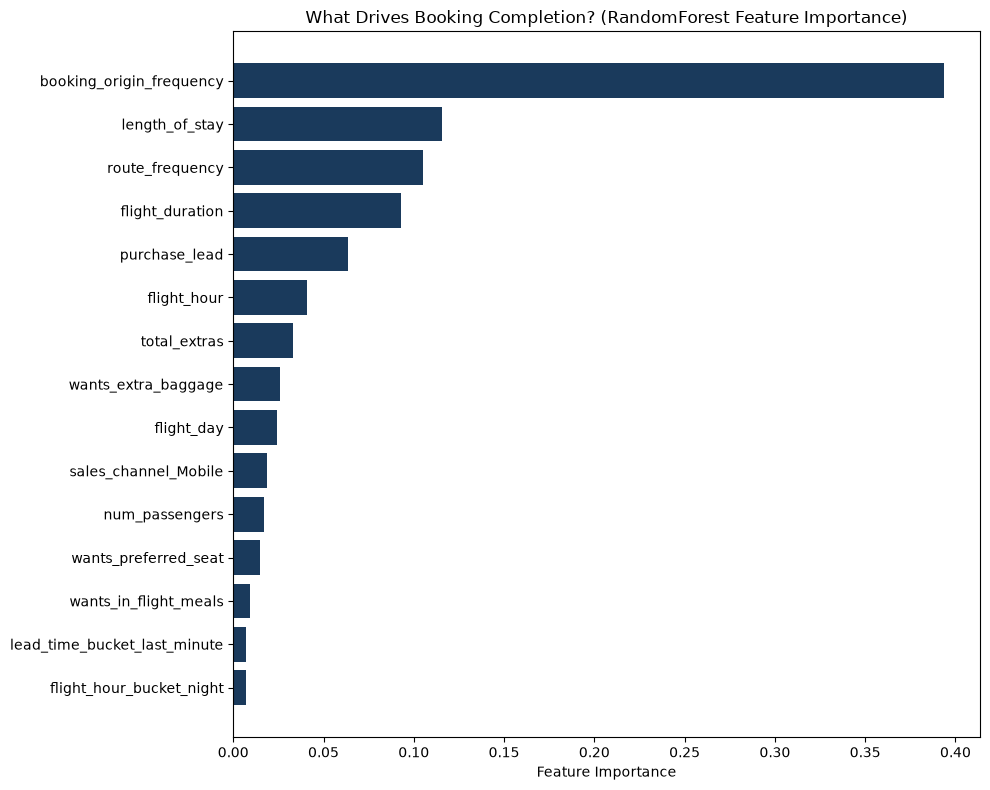

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances)

# Plot top 15
plt.figure(figsize=(10, 8))
top_n = importances.head(15)
plt.barh(top_n.index[::-1], top_n.values[::-1], color="#1a3a5c")
plt.xlabel("Feature Importance")
plt.title("What Drives Booking Completion? (RandomForest Feature Importance)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [21]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="roc_auc"
)

perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(perm_importances)

booking_origin_frequency        0.151405
length_of_stay                  0.019774
route_frequency                 0.016110
flight_duration                 0.012622
sales_channel_Mobile            0.009031
wants_extra_baggage             0.004734
purchase_lead                   0.004595
total_extras                    0.003339
wants_preferred_seat            0.002260
num_passengers                  0.001287
flight_hour                     0.000776
trip_type_RoundTrip             0.000605
lead_time_bucket_last_minute    0.000239
trip_type_OneWay                0.000202
wants_in_flight_meals           0.000159
flight_hour_bucket_evening      0.000023
lead_time_bucket_normal        -0.000014
flight_hour_bucket_morning     -0.000066
flight_hour_bucket_night       -0.000080
is_weekend_flight              -0.000119
flight_day                     -0.000220
dtype: float64


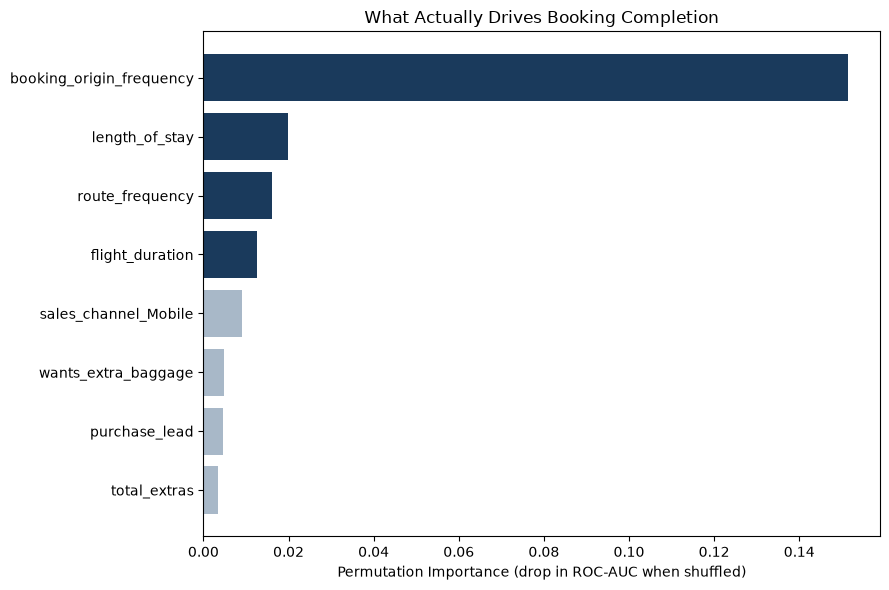

In [22]:
import matplotlib.pyplot as plt

top_n = perm_importances.head(8)

plt.figure(figsize=(9, 6))
colors = ["#1a3a5c" if v > 0.01 else "#a8b8c8" for v in top_n.values]
plt.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1])
plt.xlabel("Permutation Importance (drop in ROC-AUC when shuffled)")
plt.title("What Actually Drives Booking Completion")
plt.tight_layout()
plt.savefig("feature_importance_final.png", dpi=150)
plt.show()

SHAP values shape: (10000, 21)


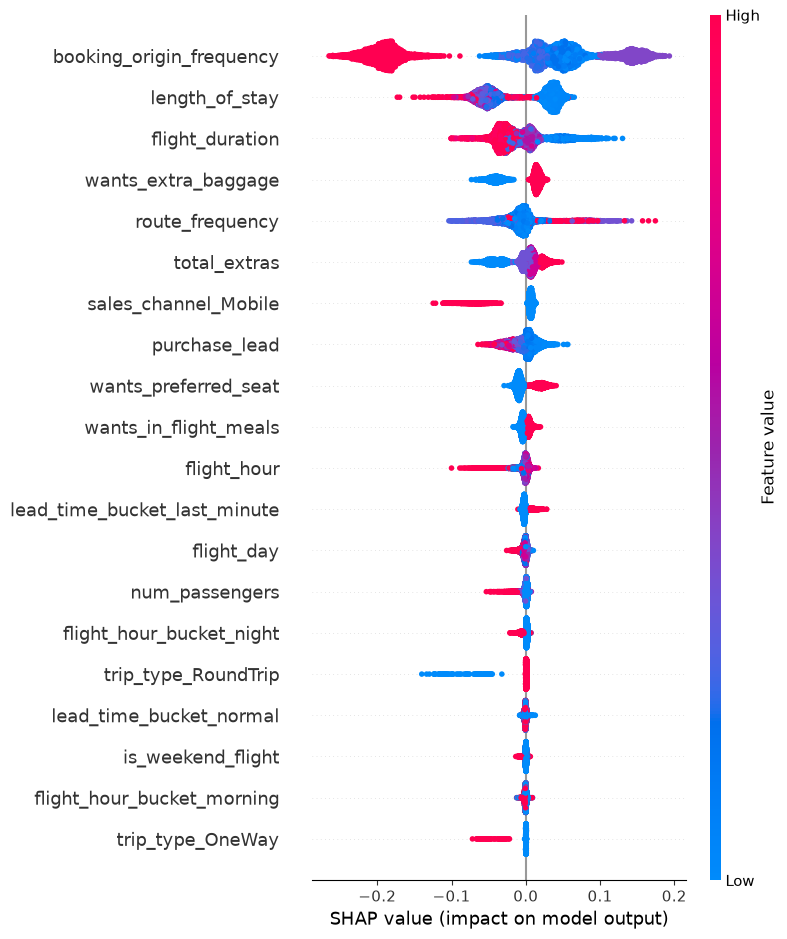

In [24]:
import numpy as np
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Correctly slice out class 1 (booking_complete = 1) from the 3D array
if shap_values.ndim == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

print("SHAP values shape:", shap_values_class1.shape)  # should be (10000, 21)

import matplotlib.pyplot as plt

shap.summary_plot(shap_values_class1, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
import pandas as pd

# Get predicted probability of booking_complete=1 for every test customer
test_with_probs = X_test.copy()
test_with_probs["predicted_prob"] = rf.predict_proba(X_test)[:, 1]
test_with_probs["actual_booked"] = y_test.values

# Sort and look at the top 10% most likely to book
top_decile = test_with_probs.sort_values("predicted_prob", ascending=False).head(int(len(test_with_probs) * 0.1))

print("Top decile average predicted probability:", top_decile["predicted_prob"].mean().round(3))
print("Top decile actual booking rate:", top_decile["actual_booked"].mean().round(3))
print("Overall actual booking rate:", test_with_probs["actual_booked"].mean().round(3))

# Profile: what does this top group actually look like?
print()
print("=== Profile of highest-likelihood customers ===")
print(top_decile[["booking_origin_frequency", "route_frequency", "length_of_stay",
                   "flight_duration", "purchase_lead", "total_extras"]].mean().round(2))

Top decile average predicted probability: 0.722
Top decile actual booking rate: 0.418
Overall actual booking rate: 0.15

=== Profile of highest-likelihood customers ===
booking_origin_frequency    6110.92
route_frequency              694.72
length_of_stay                14.72
flight_duration                6.44
purchase_lead                 77.42
total_extras                   1.94
dtype: float64


In [26]:
import numpy as np

mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
direction_corr = [np.corrcoef(X_test[col].values, shap_values_class1[:, i])[0, 1]
                   for i, col in enumerate(X_test.columns)]

shap_direction = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap,
    "value_shap_corr": direction_corr
}).sort_values("mean_abs_shap", ascending=False)

print(shap_direction.head(10).to_string(index=False))

                 feature  mean_abs_shap  value_shap_corr
booking_origin_frequency       0.108544        -0.854355
          length_of_stay       0.044268        -0.565353
         flight_duration       0.026193        -0.786217
     wants_extra_baggage       0.023947         0.980325
         route_frequency       0.017864         0.322332
            total_extras       0.016726         0.888824
    sales_channel_Mobile       0.014466        -0.979397
           purchase_lead       0.012853        -0.820098
    wants_preferred_seat       0.012491         0.949620
   wants_in_flight_meals       0.004527         0.863563


`value_shap_corr` close to **+1** means higher feature values push the prediction *toward* booking;
close to **-1** means higher values push *away* from booking. This tells us direction, which the
earlier permutation importance chart (magnitude only) couldn't show.

In [27]:
origin_summary = df.groupby("booking_origin").agg(
    total_bookings=("booking_complete", "size"),
    booking_rate=("booking_complete", "mean")
).sort_values("total_bookings", ascending=False)

print("Top origin markets by volume:")
print(origin_summary.head(10).round(4))

Top origin markets by volume:
                total_bookings  booking_rate
booking_origin                              
Australia                17872        0.0504
Malaysia                  7174        0.3440
South Korea               4559        0.1013
Japan                     3885        0.1230
China                     3387        0.2049
Indonesia                 2369        0.2596
Taiwan                    2077        0.1078
Thailand                  2030        0.2315
India                     1270        0.1031
New Zealand               1074        0.0503


## Conclusion

**Is the data viable?** Yes — the model achieves ROC-AUC ≈ 0.75-0.76 (stable across 5-fold CV,
confirmed on the held-out test set), and the top 10% of customers by predicted probability book
at **41.8%**, nearly 3x the overall base rate of **15.0%**. That's enough signal to meaningfully
prioritize marketing spend, though not enough to confidently predict any single customer's behavior.

**What drives booking completion?**
- **Origin market** is the single strongest driver, but the effect is country-specific rather than
  a simple "small markets convert better" pattern — Australia and New Zealand notably underperform
  (~5% each) despite Australia being the single largest market by volume, while mid-sized markets
  like Malaysia convert far better (34.4%).
- **Shorter trips, shorter-haul flights, and wanting optional extras** (baggage, seat, meals) all
  push toward completion.
- **Booking via Internet (not Mobile)**, closer to the travel date, for a round trip with fewer
  passengers, also increases the likelihood of completion.
- Most engineered time-based features (weekend flag, hour bucket, flight day) contributed
  negligibly — several were statistically indistinguishable from noise under permutation testing.

**Recommendation:** Use this model to prioritize outreach toward customers matching the
above profile, particularly by origin country performance, rather than to make high-confidence
individual predictions.

In [28]:
shap_direction.to_csv("final_shap_direction.csv", index=False)
origin_summary.to_csv("origin_country_summary.csv", index=True) 
print("Exported final_shap_direction.csv and origin_country_summary.csv")

Exported final_shap_direction.csv and origin_country_summary.csv
